In [7]:
%cd ..

/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling


In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Metadaten laden (für das Target y)
df_meta = pd.read_csv("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview_reduced.csv")
print(df_meta.shape)
y = df_meta["is_metal"].values  # Dein Target-Vektor

# Hocheffiziente SOAP-Features laden (für das X)
X = np.load("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_soap_features_reduced.npy")  # Deine Feature-Matrix
print(X.shape)
print('Number of entries: ',df_meta.shape[0])
df_meta.head()


(8000, 10)
(8000, 48870)
Number of entries:  8000


,entry_id,name,formula,spacegroup,crystal_structure,band_gap,is_metal,energy_above_hull,is_stable,delta_e
0,647362,CaInBr3,Br6Ca2In2,Cmcm,orthorhombic,3.243,False,0.000151,False,-1.707352
1,1377987,CaTlBr3,Br6Ca2Tl2,Cmcm,orthorhombic,3.857,False,0.000000,True,-1.794562
2,14334,CdInBr3,Br12Cd4In4,Pnma,orthorhombic,2.176,False,0.007316,False,-0.990649
3,647360,CrInBr3,Br12Cr4In4,P21/c,monoclinic,0.431,False,0.040698,False,-0.846143
4,1368552,CsAgBr3,Ag2Br6Cs2,I4/mmm,tetragonal,0.000,True,0.000000,True,-1.126859


In [13]:
# Direkt splitten und trainieren!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train Form:", X_train.shape)  # Bereit für Random Forest, Ridge Regression etc.

X_train Form: (6400, 48870)


## Analyse Dataset
How many metals vs. semiconductors?
How many stabel structures?

is_metal
True     5548
False    2452
Name: count, dtype: int64


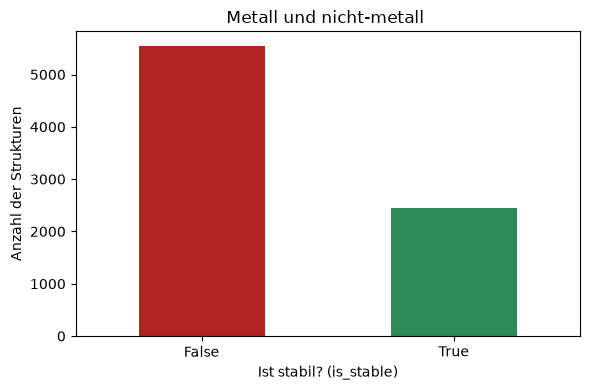

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Angenommen, dein DataFrame heißt 'df_combined' und die Spalte 'is_stable'
# 1. Häufigkeiten zählen
counts = df_meta["is_metal"].value_counts()
print(counts)

# 2. Plot erstellen
plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color=["firebrick", "seagreen"])  # Farben für False und True

# 3. Diagramm beschriften
plt.title("Metall und nicht-metall " \
"")
plt.xlabel("Ist stabil? (is_stable)")
plt.ylabel("Anzahl der Strukturen")
plt.xticks(
    ticks=[0, 1], labels=["False", "True"], rotation=0
)  # rotation=0 sorgt dafür, dass der Text gerade steht

# Grafik anzeigen
plt.tight_layout()
plt.show()

## Classify stability with decition trees

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Initialize the Decision Tree Classifier
# 'max_depth' limits how deep the tree grows to prevent overfitting
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Train (Fit) the model
tree_model.fit(X_train, y_train)

# 3. Make Predictions on the test data
y_pred = tree_model.predict(X_test)

# 4. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Kein Metall (False)", "Metall (True)"]))

Model Accuracy: 0.72

Classification Report:
                     precision    recall  f1-score   support

Kein Metall (False)       0.57      0.42      0.48       487
      Metall (True)       0.77      0.86      0.81      1088

           accuracy                           0.72      1575
          macro avg       0.67      0.64      0.65      1575
       weighted avg       0.70      0.72      0.71      1575



In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model,x_test, y_test, labels_x, labels_y):

    y_pred = model.predict(x_test)

    # 1. Die Confusion Matrix normalisieren ('true' normiert über die tatsächliche Achse)
    cm_percentage = confusion_matrix(y_test, y_pred, normalize="true")

    # 2. Beschriftungen für die Achsen definieren
    #labels_y = ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"]
    #labels_x = ["Kein Metall\n(False)", "Metall\n(True)"]

    # 3. Den Plot erstellen
    plt.figure(figsize=(6, 5))

    # sns.heatmap zeichnet die Matrix
    sns.heatmap(
        cm_percentage,
        annot=True,  # Schreibt die Werte in die Quadrate
        fmt=".1%",  # <--- WICHTIG: Formatiert die Zahlen als Prozent mit einer Nachkommastelle (z.B. 94.5%)
        cmap="Blues",  # Blaue Farbpalette
        xticklabels=labels_x,  # Beschriftung X-Achse
        yticklabels=labels_y,  # Beschriftung Y-Achse
        cbar=True,
        square=True,
        vmin=0,
        vmax=1,  # Setzt die Farbskala fest von 0% bis 100%
    )

    # 4. Titel und Achsenbeschriftungen
    plt.title(
        "Confusion Matrix (Prozentual) - Metall-Klassifikation",
        fontsize=14,
        pad=20,
    )
    plt.xlabel("Vorhersage des Modells (Predicted)", fontsize=12)
    plt.ylabel("Tatsächliche Struktur (Actual)", fontsize=12)

    # Grafik anzeigen
    plt.tight_layout()
    plt.show()

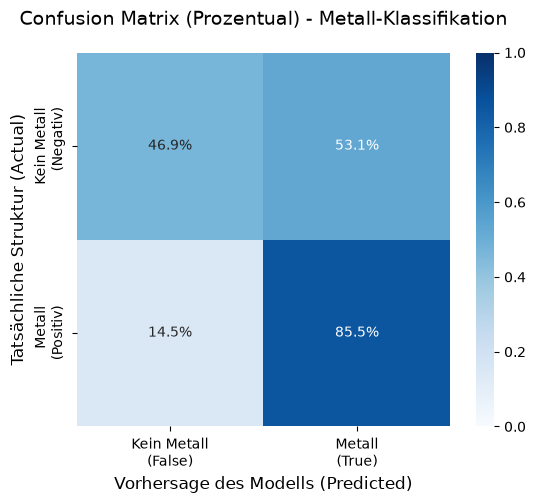

In [33]:
plot_confusion_matrix(tree_model, X_test, y_test, ["Kein Metall\n(False)", "Metall\n(True)"], ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"])

Diskussion: Positiv anzumerken ist, dass das Modell trainiert und ein Decision Tree Classifier verwendet werden kann um Metal / Non-Metal vorherzusagen. Anzumerken ist hierbei, dass das Datenset reduziert wurde, indem Strukturen mit seltenen Erden und radioaktiven Elementen entfernt wurden. Dadurch reduzierte sich der Datensatz von über 16.000 auf 8.000 Strukturen. Allerding wurde auch der SOAP Deskrptor deutlich verkürzt (ca. 50.000 statt über 200.000).

Laut Classification Report hat das Modell eine Accuracy von 74%. Das ist nicht besonders gut, aber schon mal ein Anfang. Allerdings gilt hier zu beachten, dass der Datensatz einen deutlichen Bias hat (mehr als doppelt so viele Metalle wie Nicht-Metalle). Dementsprechend ist die True-Positive Rate deutlich höher, wärend die True-Negative Rate bei nur 50% liegt!

## Random Forest Classifier
Repeat the same classification with a random forest classifier of manualy defined shape.

In [27]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier  # <--- NEUER IMPORT
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,  # Anzahl der Bäume im Wald (100 ist ein super Standardwert)
    max_depth=5,  # Maximale Tiefe pro Baum (etwas höher als beim Tree, da der Wald stabiler ist)
    class_weight="balanced",  # <--- EXTREM WICHTIG: Behebt deinen Bias/Klassen-Ungleichgewicht!
    random_state=42,  # Macht die Ergebnisse reproduzierbar
    n_jobs=-1,  # Nutzen aller CPU-Kerne für blitzschnelles paralleles Training
)

# 2. Train (Fit) the model
print("Trainiere Random Forest (das kann bei 50.000 Spalten etwas dauern)...")
rf_model.fit(X_train, y_train)
print("Training abgeschlossen!")

# 3. Make Predictions on the test data
y_pred = rf_model.predict(X_test)

# 4. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=["Kein Metall (False)", "Metall (True)"]
    )
)

Trainiere Random Forest (das kann bei 50.000 Spalten etwas dauern)...
Training abgeschlossen!
Model Accuracy: 0.78

Classification Report:
                     precision    recall  f1-score   support

Kein Metall (False)       0.64      0.60      0.62       488
      Metall (True)       0.83      0.85      0.84      1112

           accuracy                           0.78      1600
          macro avg       0.73      0.73      0.73      1600
       weighted avg       0.77      0.78      0.77      1600



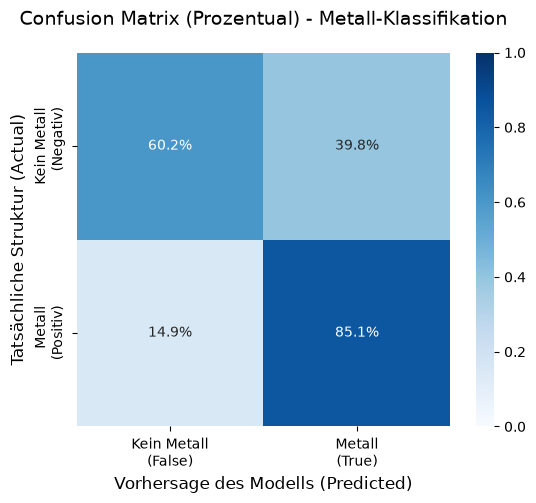

In [34]:
plot_confusion_matrix(rf_model, X_test, y_test, ["Kein Metall\n(False)", "Metall\n(True)"], ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"])


Hinweis zum Random Forest: 

Der class_weight='balanced' Effekt: Der Algorithmus berechnet mathematisch ein höheres Strafmaß, wenn er ein Nicht-Metall falsch klassifiziert. Dadurch traut sich das Modell im Zweifel eher, "Nicht-Metall" vorherzusagen. Deine Gesamt-Accuracy könnte dadurch minimal sinken, aber dein Recall für die Nicht-Metalle wird deutlich steigen, was deine physikalische Vorhersagekraft viel realistischer macht.

## Grid Search zum besten Modell
Im Folgenden wird ein Grid Search verwendet um die besten Hyperparameter für den Random Forest Classifier zu finden.

In [29]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Das Basis-Modell definieren
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

# 2. Den Suchraum (Grid) festlegen
# Tipp: Halte die Liste kurz, da jede Kombination mit jeder multipliziert wird!
param_grid = {
    "n_estimators": [50, 100],  # Anzahl der Bäume
    "max_depth": [5, 10, None],  # Tiefe der Bäume (None bedeutet unbegrenzt)
    "min_samples_split": [2, 5],  # Mindestanzahl an Strukturen für einen Split
}

# 3. Grid Search initialisieren
# cv=3 bedeutet 3-fache Kreuzvalidierung. scoring='f1_macro' ist extrem wichtig,
# damit das Modell für beide Klassen (Metall & Nicht-Metall) optimiert wird, trotz Bias!
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=2,  # Zeigt dir den Fortschritt live an
    n_jobs=-1,  # Nutzt alle CPU-Kerne parallel
)

# 4. Suche starten
print("Starte Grid Search über alle Parameter-Kombinationen...")
grid_search.fit(X_train, y_train)

# 5. Bestes Ergebnis anzeigen
print("\n=== GRID SEARCH BEENDET ===")
print(f"Bester F1-Macro-Score: {grid_search.best_score_:.2f}")
print("Beste Parameter-Kombination:")
print(grid_search.best_params_)

# Das beste Modell direkt für Vorhersagen nutzen
best_rf_model = grid_search.best_estimator_

Starte Grid Search über alle Parameter-Kombinationen...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=  10.6s
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=  10.7s
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=  10.7s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=  10.8s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=  10.7s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=  11.0s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=  11.0s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=  11.0s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   5.2s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=   6.9s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=

In [35]:
y_pred = best_rf_model.predict(X_test)

# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=["Kein Metall (False)", "Metall (True)"]
    ))

Model Accuracy: 0.88

Classification Report:
                     precision    recall  f1-score   support

Kein Metall (False)       0.77      0.88      0.82       488
      Metall (True)       0.94      0.89      0.91      1112

           accuracy                           0.88      1600
          macro avg       0.86      0.88      0.87      1600
       weighted avg       0.89      0.88      0.89      1600



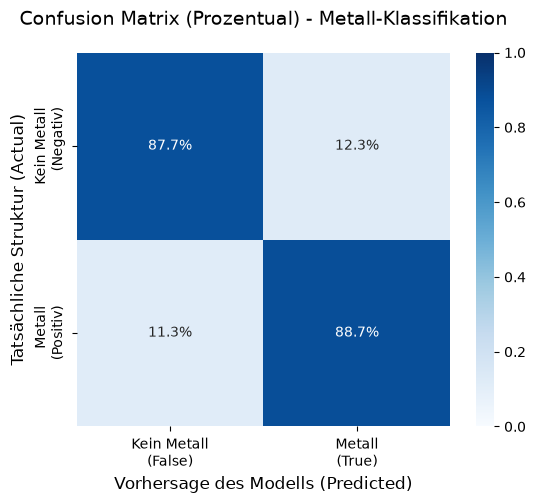

In [36]:
plot_confusion_matrix(best_rf_model, X_test, y_test, ["Kein Metall\n(False)", "Metall\n(True)"], ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"])


In [57]:
def predict_perovskite(model, X_matrix, df_metadata, search_value):
    # Liefert zu einer Struktur die Prediction und wichtige Infos

    # Es kann wahlweise nach Name oder nach Entry_ID gesucht werden
    if isinstance(search_value, (int, np.integer)):
        id_column = df_metadata.columns[0]
        row_index = df_metadata[df_metadata[id_column] == search_value].index
    else:
        row_index = df_metadata[df_metadata["name"] == search_value].index

    # Prüfen, ob der Eintrag überhaupt existiert
    if len(row_index) == 0:
        print(f"❌ Eintrag '{search_value}' wurde im Datensatz nicht gefunden.")
        return None

    # Da der Index eine Liste sein kann, nehmen wir den ersten Treffer
    idx = row_index[0]

    # Den passenden SOAP-Vektor aus der Matrix X holen und für das Modell formen (reshape)
    # .reshape(1, -1) wird von Scikit-Learn für einzelne Vorhersagen zwingend verlangt
    soap_vector = X_matrix[idx].reshape(1, -1)

    # Vorhersage und Wahrscheinlichkeit berechnen
    prediction = model.predict(soap_vector)[0] # [0] reshaped von array mit einem Eintrag zu einem Element


    
    print("=" * 60)
    print(" GEFUNDENER DATENBANK-EINTRAG:")
    print("=" * 60)
    # Gibt die komplette Zeile des DataFrames sauber aus
    print(df_metadata.iloc[idx].to_string())
    print()
    print(f"Vorhersage: Is-metal = {prediction}")



# Abfrage über die Entry_ID
predict_perovskite(model=rf_model, X_matrix=X, df_metadata=df_meta, search_value=647362)

# Abfrage über den Namen
predict_perovskite(model=rf_model, X_matrix=X, df_metadata=df_meta, search_value="KCuBr3")

predict_perovskite(model=rf_model, X_matrix=X, df_metadata=df_meta, search_value=1347383)
predict_perovskite(model=rf_model, X_matrix=X, df_metadata=df_meta, search_value=1349360)


 GEFUNDENER DATENBANK-EINTRAG:
entry_id                   647362
name                      CaInBr3
formula                 Br6Ca2In2
spacegroup                   Cmcm
crystal_structure    orthorhombic
band_gap                    3.243
is_metal                    False
energy_above_hull        0.000151
is_stable                   False
delta_e                 -1.707352

Vorhersage: Is-metal = False
 GEFUNDENER DATENBANK-EINTRAG:
entry_id                1347383
name                     KCuBr3
formula               Br12Cu4K4
spacegroup                P21/c
crystal_structure    monoclinic
band_gap                    0.0
is_metal                   True
energy_above_hull      0.021007
is_stable                 False
delta_e               -1.060371

Vorhersage: Is-metal = False
 GEFUNDENER DATENBANK-EINTRAG:
entry_id                1347383
name                     KCuBr3
formula               Br12Cu4K4
spacegroup                P21/c
crystal_structure    monoclinic
band_gap                   

## Wichtiger Hinweis:
Beachte, dass die Abfrage nach Namen nicht eindeutig ist, da dieselbe Summenformel mehrere Kristallstukturen aufweisen kann.

# =========================================================

## Try everything with Coulomb Matrix Describtor

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Metadaten laden (für das Target y)
df_meta = pd.read_csv("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview_reduced_CoulombM.csv")
print(df_meta.shape)
y = df_meta["is_metal"].values  # Dein Target-Vektor

# Hocheffiziente SOAP-Features laden (für das X)
X = np.load("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_coulomb_features_reduced.npy")  # Deine Feature-Matrix
print(X.shape)
print('Number of entries: ',df_meta.shape[0])
df_meta.head()


(7875, 10)
(7875, 900)
Number of entries:  7875


,entry_id,name,formula,spacegroup,crystal_structure,band_gap,is_metal,energy_above_hull,is_stable,delta_e
0,647362,CaInBr3,Br6Ca2In2,Cmcm,orthorhombic,3.243,False,0.000151,False,-1.707352
1,1377987,CaTlBr3,Br6Ca2Tl2,Cmcm,orthorhombic,3.857,False,0.000000,True,-1.794562
2,14334,CdInBr3,Br12Cd4In4,Pnma,orthorhombic,2.176,False,0.007316,False,-0.990649
3,647360,CrInBr3,Br12Cr4In4,P21/c,monoclinic,0.431,False,0.040698,False,-0.846143
4,1368552,CsAgBr3,Ag2Br6Cs2,I4/mmm,tetragonal,0.000,True,0.000000,True,-1.126859


In [18]:
# Direkt splitten und trainieren!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train Form:", X_train.shape)  # Bereit für Random Forest, Ridge Regression etc.

X_train Form: (6300, 900)


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Das Basis-Modell definieren
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

# 2. Den Suchraum (Grid) festlegen
# Tipp: Halte die Liste kurz, da jede Kombination mit jeder multipliziert wird!
param_grid = {
    "n_estimators": [50, 100, 200],  # Anzahl der Bäume
    "max_depth": [5, 10, None],  # Tiefe der Bäume (None bedeutet unbegrenzt)
    "min_samples_split": [2, 5, 10],  # Mindestanzahl an Strukturen für einen Split
}

# 3. Grid Search initialisieren
# cv=3 bedeutet 3-fache Kreuzvalidierung. scoring='f1_macro' ist extrem wichtig,
# damit das Modell für beide Klassen (Metall & Nicht-Metall) optimiert wird, trotz Bias!
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=2,  # Zeigt dir den Fortschritt live an
    n_jobs=-1,  # Nutzt alle CPU-Kerne parallel
)

# 4. Suche starten
print("Starte Grid Search über alle Parameter-Kombinationen...")
grid_search.fit(X_train, y_train)

# 5. Bestes Ergebnis anzeigen
print("\n=== GRID SEARCH BEENDET ===")
print(f"Bester F1-Macro-Score: {grid_search.best_score_:.2f}")
print("Beste Parameter-Kombination:")
print(grid_search.best_params_)

# Das beste Modell direkt für Vorhersagen nutzen
best_rf_model = grid_search.best_estimator_

Starte Grid Search über alle Parameter-Kombinationen...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.5s
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.5s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.4s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.3s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.2s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=   1.6s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=

In [28]:
y_pred = best_rf_model.predict(X_test)

# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=["Kein Metall (False)", "Metall (True)"]
    ))

Model Accuracy: 0.77

Classification Report:
                     precision    recall  f1-score   support

Kein Metall (False)       0.61      0.70      0.65       487
      Metall (True)       0.86      0.80      0.83      1088

           accuracy                           0.77      1575
          macro avg       0.73      0.75      0.74      1575
       weighted avg       0.78      0.77      0.77      1575



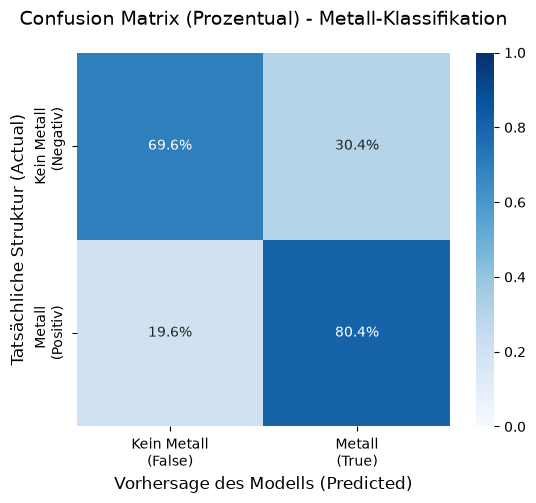

In [29]:
plot_confusion_matrix(best_rf_model, X_test, y_test, ["Kein Metall\n(False)", "Metall\n(True)"], ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"])

# ============================================================================

# Try everything with Ewald-Sum-Matrices

In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Metadaten laden (für das Target y)
df_meta = pd.read_csv("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview_reduced_EwaldM.csv")
print(df_meta.shape)
y = df_meta["is_metal"].values  # Dein Target-Vektor

# Hocheffiziente SOAP-Features laden (für das X)
X = np.load("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_ewald_features_reduced.npy")  # Deine Feature-Matrix
print(X.shape)
print('Number of entries: ',df_meta.shape[0])
df_meta.head()


(7875, 10)
(7875, 900)
Number of entries:  7875


,entry_id,name,formula,spacegroup,crystal_structure,band_gap,is_metal,energy_above_hull,is_stable,delta_e
0,647362,CaInBr3,Br6Ca2In2,Cmcm,orthorhombic,3.243,False,0.000151,False,-1.707352
1,1377987,CaTlBr3,Br6Ca2Tl2,Cmcm,orthorhombic,3.857,False,0.000000,True,-1.794562
2,14334,CdInBr3,Br12Cd4In4,Pnma,orthorhombic,2.176,False,0.007316,False,-0.990649
3,647360,CrInBr3,Br12Cr4In4,P21/c,monoclinic,0.431,False,0.040698,False,-0.846143
4,1368552,CsAgBr3,Ag2Br6Cs2,I4/mmm,tetragonal,0.000,True,0.000000,True,-1.126859


In [31]:
# Direkt splitten und trainieren!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train Form:", X_train.shape)  # Bereit für Random Forest, Ridge Regression etc.

X_train Form: (6300, 900)


In [32]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Das Basis-Modell definieren
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

# 2. Den Suchraum (Grid) festlegen
# Tipp: Halte die Liste kurz, da jede Kombination mit jeder multipliziert wird!
param_grid = {
    "n_estimators": [50, 100, 200],  # Anzahl der Bäume
    "max_depth": [5, 10, None],  # Tiefe der Bäume (None bedeutet unbegrenzt)
    "min_samples_split": [2, 5, 10],  # Mindestanzahl an Strukturen für einen Split
}

# 3. Grid Search initialisieren
# cv=3 bedeutet 3-fache Kreuzvalidierung. scoring='f1_macro' ist extrem wichtig,
# damit das Modell für beide Klassen (Metall & Nicht-Metall) optimiert wird, trotz Bias!
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=2,  # Zeigt dir den Fortschritt live an
    n_jobs=-1,  # Nutzt alle CPU-Kerne parallel
)

# 4. Suche starten
print("Starte Grid Search über alle Parameter-Kombinationen...")
grid_search.fit(X_train, y_train)

# 5. Bestes Ergebnis anzeigen
print("\n=== GRID SEARCH BEENDET ===")
print(f"Bester F1-Macro-Score: {grid_search.best_score_:.2f}")
print("Beste Parameter-Kombination:")
print(grid_search.best_params_)

# Das beste Modell direkt für Vorhersagen nutzen
best_rf_model = grid_search.best_estimator_

Starte Grid Search über alle Parameter-Kombinationen...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.5s
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.5s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.2s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.3s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.4s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=   1.4s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=

In [36]:
y_pred = best_rf_model.predict(X_test)

# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=["Kein Metall (False)", "Metall (True)"]
    ))

Model Accuracy: 0.78

Classification Report:
                     precision    recall  f1-score   support

Kein Metall (False)       0.62      0.74      0.67       487
      Metall (True)       0.87      0.80      0.83      1088

           accuracy                           0.78      1575
          macro avg       0.75      0.77      0.75      1575
       weighted avg       0.79      0.78      0.79      1575



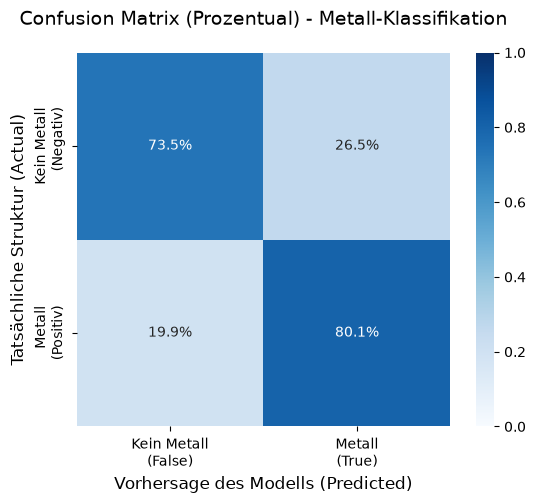

In [37]:
plot_confusion_matrix(best_rf_model, X_test, y_test, ["Kein Metall\n(False)", "Metall\n(True)"], ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"])